<a href="https://colab.research.google.com/github/brenda96011/IA-2026-2/blob/main/tema2/09_UNAM_AI_Actividad_Laboratorio_2_8_A_estrella_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & MMM \\[6pt]
\textbf{Fecha de realización:} & 03/03/2026
\end{array}

</center>

# Introducción

Revisar el siguiente video para comprender el problema:
https://www.youtube.com/watch?v=yxN6yR_7yJM

##Desarollo

El siguiente código ayudará mediante el algoritmo A* a encontrar el camino más optimo:

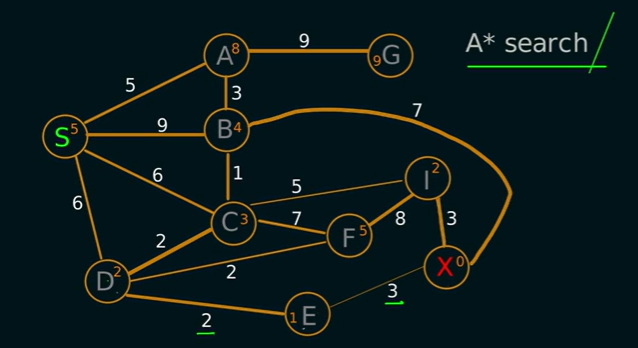

In [ ]:
import heapq

def a_star(grafo, heuristicas, inicio, destino):
    # priority_queue guardará tuplas: (f_score, nodo, camino_actual, g_score)
    frontera = [(heuristicas[inicio], inicio, [inicio], 0)]
    visitados = set()

    while frontera:
        # Extraemos el nodo con el menor f(n) = g(n) + h(n)
        (f, nodo_actual, camino, g) = heapq.heappop(frontera)

        if nodo_actual == destino:
            return camino, g

        if nodo_actual not in visitados:
            visitados.add(nodo_actual)

            # Explorar vecinos
            for vecino, costo in grafo[nodo_actual].items():
                if vecino not in visitados:
                    nuevo_g = g + costo
                    nuevo_f = nuevo_g + heuristicas[vecino]
                    nuevo_camino = camino + [vecino]
                    heapq.heappush(frontera, (nuevo_f, vecino, nuevo_camino, nuevo_g))

    return None, float('inf')

# 1. Definición del Grafo (según las conexiones de tu imagen)
grafo = {
    'S': {'A': 5, 'B': 9, 'D': 6},
    'A': {'S': 5, 'B': 3, 'G': 9},
    'B': {'S': 9, 'A': 3, 'C': 1},
    'C': {'B': 1, 'D': 2, 'F': 7, 'I': 5},
    'D': {'S': 6, 'C': 2, 'E': 2},
    'E': {'D': 2, 'X': 3},
    'F': {'C': 7, 'I': 8, 'X': 2},
    'I': {'C': 5, 'F': 8, 'X': 3},
    'G': {'A': 9},
    'X': {'E': 3, 'F': 2, 'I': 3}
}

# 2. Valores de la Heurística h(n) (los números pequeños arriba de cada letra)
heuristicas = {
    'S': 5, 'A': 8, 'B': 4, 'C': 3, 'D': 2,
    'E': 1, 'F': 5, 'I': 2, 'G': 9, 'X': 0
}

# Ejecución
camino_optimo, costo_total = a_star(grafo, heuristicas, 'S', 'X')

print(f"Camino encontrado: {' -> '.join(camino_optimo)}")
print(f"Costo total (f): {costo_total}")

Camino encontrado: S -> D -> E -> X
Costo total (f): 11


Otros ejemplos son como a continuación

In [ ]:
pip install matplotlib


In [ ]:
import heapq

class Nodo:
    def __init__(self, estado, padre=None, costo=0, heuristica=0):
        self.estado = estado
        self.padre = padre
        self.costo = costo
        self.heuristica = heuristica

    def __lt__(self, otro):
        return (self.costo + self.heuristica) < (otro.costo + otro.heuristica)

def a_estrella(inicial, objetivo, heuristica):
    frontera = []
    heapq.heappush(frontera, Nodo(inicial, None, 0, heuristica(inicial, objetivo)))

    explorado = set()

    while frontera:
        actual = heapq.heappop(frontera)

        if actual.estado == objetivo:
            # Construir el camino desde el nodo objetivo hasta el inicial
            camino = []
            while actual:
                camino.append(actual.estado)
                actual = actual.padre
            return list(reversed(camino))

        explorado.add(actual.estado)
       #se inicializa un ciclo for para encontrar los vecinos cercanos
        for vecino in expandir(actual.estado):
            if vecino not in explorado:
                nuevo_costo = actual.costo + 1
                nuevo_nodo = Nodo(vecino, actual, nuevo_costo, heuristica(vecino, objetivo))
                heapq.heappush(frontera, nuevo_nodo)

    return None

def expandir(estado):
    # Esta función debe ser personalizada según el problema específico
    # Aquí hay un ejemplo simple para un tablero cuadrado de 3x3
    movimientos = [(0, 1), (1, 0), (0, -1), (-1, 0)]
    filas, columnas = 3, 3
    r, c = estado
    vecinos = [(r + dr, c + dc) for dr, dc in movimientos if 0 <= r + dr < filas and 0 <= c + dc < columnas]
    return vecinos

def heuristica_euclidiana(posicion, objetivo):
    # Heurística euclidiana para la distancia entre dos puntos en un espacio 2D
    return ((posicion[0] - objetivo[0]) ** 2 + (posicion[1] - objetivo[1]) ** 2) ** 0.5

# Ejemplo de uso
inicio = (0, 0)
meta = (2, 2)
ruta = a_estrella(inicio, meta, heuristica_euclidiana)

print("Camino encontrado:", ruta)

Camino encontrado: [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2)]


**Ahora mostrado como Nodos de un grafo:**

In [ ]:
pip install networkx


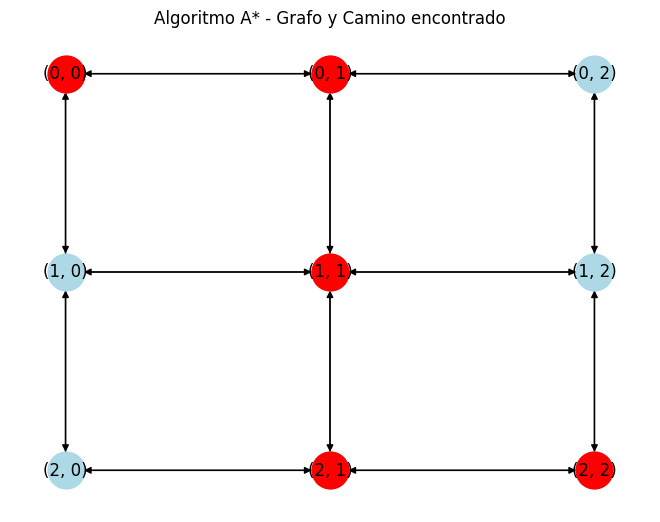

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

class Nodo:
    def __init__(self, estado, padre=None, costo=0, heuristica=0):
        self.estado = estado
        self.padre = padre
        self.costo = costo
        self.heuristica = heuristica

    def __lt__(self, otro):
        return (self.costo + self.heuristica) < (otro.costo + otro.heuristica)

def a_estrella(inicial, objetivo, heuristica):
    frontera = []
    heapq.heappush(frontera, Nodo(inicial, None, 0, heuristica(inicial, objetivo)))

    explorado = set()

    while frontera:
        actual = heapq.heappop(frontera)

        if actual.estado == objetivo:
            # Construir el camino desde el nodo objetivo hasta el inicial
            camino = []
            while actual:
                camino.append(actual.estado)
                actual = actual.padre
            return list(reversed(camino))

        explorado.add(actual.estado)

        for vecino in expandir(actual.estado):
            if vecino not in explorado:
                nuevo_costo = actual.costo + 1
                nuevo_nodo = Nodo(vecino, actual, nuevo_costo, heuristica(vecino, objetivo))
                heapq.heappush(frontera, nuevo_nodo)

    return None

def expandir(estado):
    # Esta función debe ser personalizada según el problema específico
    # Aquí hay un ejemplo simple para un tablero cuadrado de 3x3
    movimientos = [(0, 1), (1, 0), (0, -1), (-1, 0)]
    filas, columnas = 3, 3
    r, c = estado
    vecinos = [(r + dr, c + dc) for dr, dc in movimientos if 0 <= r + dr < filas and 0 <= c + dc < columnas]
    return vecinos

def heuristica_euclidiana(posicion, objetivo):
    # Heurística euclidiana para la distancia entre dos puntos en un espacio 2D
    return ((posicion[0] - objetivo[0]) ** 2 + (posicion[1] - objetivo[1]) ** 2) ** 0.5

# Ejemplo de uso
inicio = (0, 0)
meta = (2, 2)
ruta = a_estrella(inicio, meta, heuristica_euclidiana)

# Crear un grafo dirigido
G = nx.DiGraph()

# Agregar nodos al grafo
for i in range(3):
    for j in range(3):
        G.add_node((i, j))

# Agregar arcos al grafo
for i in range(3):
    for j in range(3):
        vecinos = expandir((i, j))
        G.add_edges_from([((i, j), vecino) for vecino in vecinos])

# Visualizar el grafo
pos = {(i, j): (j, -i) for i in range(3) for j in range(3)}  # Ajustar la posición de los nodos
nx.draw(G, pos, with_labels=True, node_size=700, node_color="lightblue")

# Resaltar el camino encontrado
nx.draw_networkx_nodes(G, pos, nodelist=ruta, node_color="red", node_size=700)

plt.title('Algoritmo A* - Grafo y Camino encontrado')
plt.show()

Camino encontrado: [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2)]

#El submarino

In [ ]:
import heapq
import random
import os

class SubmarinoGame:
    def __init__(self, filas=6, columnas=6, num_obstaculos=5):
        self.filas = filas
        self.columnas = columnas
        self.inicio = (0, 0)
        self.meta = (filas - 1, columnas - 1)
        self.obstaculos = self._generar_obstaculos(num_obstaculos)
        self.pos_jugador = self.inicio
        self.pos_ia = self.inicio

    def _generar_obstaculos(self, n):
        obs = set()
        while len(obs) < n:
            pos = (random.randint(0, self.filas-1), random.randint(0, self.columnas-1))
            if pos != self.inicio and pos != self.meta:
                obs.add(pos)
        return obs

    def heuristica(self, a, b):
        # Distancia Manhattan: |x1 - x2| + |y1 - y2|
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def obtener_vecinos(self, pos):
        r, c = pos
        vecinos = []
        for dr, dc in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.filas and 0 <= nc < self.columnas and (nr, nc) not in self.obstaculos:
                vecinos.append((nr, nc))
        return vecinos

    def a_estrella_paso(self, inicio):
        """La IA calcula el siguiente mejor paso."""
        frontera = []
        heapq.heappush(frontera, (0, inicio, []))
        visitados = {inicio: 0}

        while frontera:
            (costo, actual, camino) = heapq.heappop(frontera)

            if actual == self.meta:
                return camino[0] if camino else actual

            for vecino in self.obtener_vecinos(actual):
                nuevo_costo = visitados[actual] + 1
                if vecino not in visitados or nuevo_costo < visitados[vecino]:
                    visitados[vecino] = nuevo_costo
                    prioridad = nuevo_costo + self.heuristica(vecino, self.meta)
                    heapq.heappush(frontera, (prioridad, vecino, camino + [vecino]))
        return inicio

    def dibujar_tablero(self):
        os.system('cls' if os.name == 'nt' else 'clear')
        print(f"\n--- Carrera de Submarinos --- Meta: {self.meta}")
        for r in range(self.filas):
            fila_str = ""
            for c in range(self.columnas):
                pos = (r, c)
                if pos == self.pos_jugador and pos == self.pos_ia: fila_str += " 🤖🧑"
                elif pos == self.pos_jugador: fila_str += " 🧑 "
                elif pos == self.pos_ia: fila_str += " 🤖 "
                elif pos == self.meta: fila_str += " 🚩 "
                elif pos in self.obstaculos: fila_str += " 💣 "
                else: fila_str += " .  "
            print(fila_str)
        print("\nControles: W (arriba), S (abajo), A (izq), D (der)")

    def jugar(self):
        while True:
            self.dibujar_tablero()

            # Turno Jugador
            mov = input("Tu turno (WASD): ").upper()
            dr, dc = 0, 0
            if mov == 'W': dr = -1
            elif mov == 'S': dr = 1
            elif mov == 'A': dc = -1
            elif mov == 'D': dc = 1

            nueva_pos = (self.pos_jugador[0] + dr, self.pos_jugador[1] + dc)
            if nueva_pos in self.obtener_vecinos(self.pos_jugador):
                self.pos_jugador = nueva_pos
            else:
                print("¡Movimiento inválido o choque con mina!")

            if self.pos_jugador == self.meta:
                self.dibujar_tablero()
                print("¡FELICIDADES! ¡Llegaste primero!")
                break

            # Turno IA
            print("La IA está pensando...")
            self.pos_ia = self.a_estrella_paso(self.pos_ia)

            if self.pos_ia == self.meta:
                self.dibujar_tablero()
                print("¡LA IA HA GANADO! Mejor suerte la próxima.")
                break

if __name__ == "__main__":
    juego = SubmarinoGame()
    juego.jugar()


--- Carrera de Submarinos --- Meta: (5, 5)
 🤖🧑 .   .   .   .   💣 
 .   .   💣  .   .   .  
 .   .   💣  .   .   .  
 .   .   .   .   .   .  
 .   .   .   .   .   .  
 .   💣  .   💣  .   🚩 

Controles: W (arriba), S (abajo), A (izq), D (der)
¡Movimiento inválido o choque con mina!
La IA está pensando...

--- Carrera de Submarinos --- Meta: (5, 5)
 🧑  🤖  .   .   .   💣 
 .   .   💣  .   .   .  
 .   .   💣  .   .   .  
 .   .   .   .   .   .  
 .   .   .   .   .   .  
 .   💣  .   💣  .   🚩 

Controles: W (arriba), S (abajo), A (izq), D (der)
¡Movimiento inválido o choque con mina!
La IA está pensando...

--- Carrera de Submarinos --- Meta: (5, 5)
 🧑  .   🤖  .   .   💣 
 .   .   💣  .   .   .  
 .   .   💣  .   .   .  
 .   .   .   .   .   .  
 .   .   .   .   .   .  
 .   💣  .   💣  .   🚩 

Controles: W (arriba), S (abajo), A (izq), D (der)
¡Movimiento inválido o choque con mina!
La IA está pensando...

--- Carrera de Submarinos --- Meta: (5, 5)
 🧑  .   .   🤖  .   💣 
 .   .   💣  .   .   .  
 .   .